In [1]:
import pandas as pd
from pathlib import Path

# 1. Defining the base directory (Moving up from notebooks/python to root)
BASE_DIR = Path.cwd().parent.parent

# 2. Defining the exact path to the cleaned data
data_path = BASE_DIR / 'data' / 'cleaned' / 'trade_summary.csv'

# 3. Access file with a safety check
if not data_path.exists():
    print(f"❌ File NOT found at: {data_path}")
    print(f"Check if your folder names are 'data' and 'cleaned' (lowercase).")
else:
    # Load using the PATH object, NOT the string 'trade_summary.csv'
    df_trade = pd.read_csv(data_path)
    print("✅ File loaded successfully.")

    # 4. Clean Numeric Columns
    cols_to_fix = ['commercial_imports', 'government_imports', 'total', 
                   'domestic_fob', 're_exports', 'total_fob', 'trade_balance']

    for col in cols_to_fix:
        # We use .astype(str) to handle any unexpected numeric/NaN types before stripping commas
        df_trade[col] = df_trade[col].astype(str).str.replace(',', '').astype(float)

    # 5. Date Construction
    df_trade['date'] = pd.to_datetime(df_trade['year'].astype(str) + '-' + df_trade['month'], format='%Y-%B')
    df_trade = df_trade.set_index('date').sort_index()

    # 6. Rename columns for clarity
    df_trade = df_trade.rename(columns={
        'total': 'total_imports',
        'domestic_fob': 'domestic_exports',
        'total_fob': 'total_exports'
    })

    # 7. Feature Engineering
    df_trade['export_import_ratio'] = (df_trade['total_exports'] / df_trade['total_imports']) * 100
    df_trade['re_export_share'] = (df_trade['re_exports'] / df_trade['total_exports']) * 100

    # Preview and Save
    print(df_trade.head())
    # Save to the SAME cleaned folder or root as per your preference
    df_trade.to_csv(BASE_DIR / 'data' / 'cleaned' / 'trade_cleaned.csv')

✅ File loaded successfully.
            year      month  commercial_imports  government_imports  \
date                                                                  
1998-08-01  1998     August            14786.66              736.34   
1998-09-01  1998  September            16438.24              511.11   
1998-10-01  1998    October            16189.14              980.93   
1998-11-01  1998   November            13424.42              395.24   
1998-12-01  1998   December            17529.81              516.13   

            total_imports  domestic_exports  re_exports  total_exports  \
date                                                                     
1998-08-01       15522.99           8642.42      506.74        9149.16   
1998-09-01       16949.35           9222.37      639.03        9861.40   
1998-10-01       17170.07           9310.95      572.66        9883.61   
1998-11-01       13819.65           8633.71      455.17        9088.89   
1998-12-01       18045.94     

## 1. External Sector Analysis. 
This phase focuses on the 'Health of the Balance of Payments' by examining how Kenya's trade relationships have evolved.
 ### Performance & Momentum

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from pathlib import Path

# 1. Setup (Using the pathlib logic we established)
BASE_DIR = Path.cwd().parent.parent
data_file = BASE_DIR / 'data' / 'cleaned' / 'trade_cleaned.csv'
df_trade = pd.read_csv(data_file, index_col='date', parse_dates=True)

# 2. Analysis: Calculating Growth Momentum
df_trade_yoy = df_trade[['total_imports', 'total_exports']].pct_change(periods=12) * 100

# 3. Analysis: Seasonal Decomposition to see the "Underlying" Deficit
# Interpolation ensures the decomposition doesn't fail on missing months
ts_decomp = df_trade['trade_balance'].interpolate(method='linear')
decomp = seasonal_decompose(ts_decomp, model='additive', period=12)

### Structural Trade Deficit
Observation: Kenya exhibits a persistent "scissors" pattern where imports grow at a steeper trajectory than exports.

Significance: A widening trade deficit exerts downward pressure on the Kenyan Shilling (KES) as more foreign currency is required to pay for imports than is earned through exports.

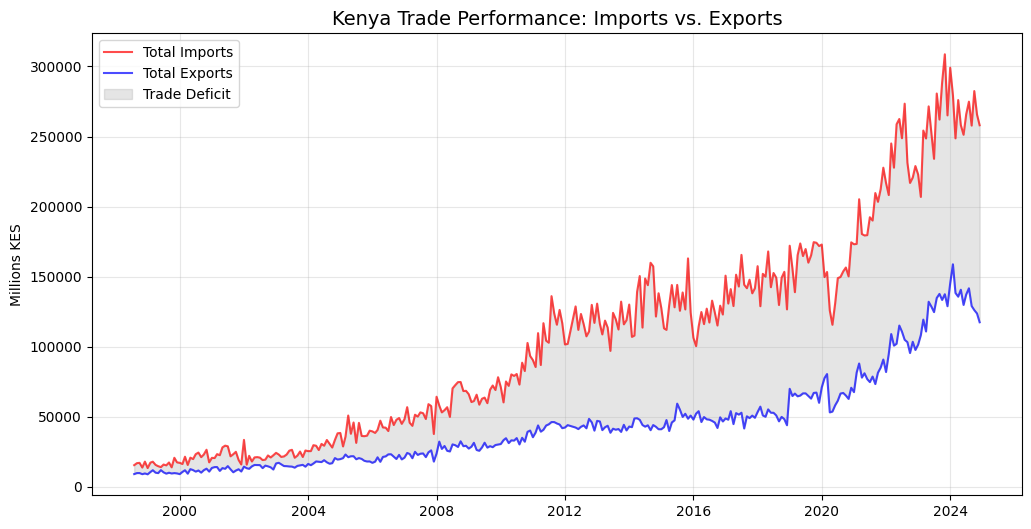

In [3]:
# VISUALIZATION 1: Trade Performance & Coverage
plt.figure(figsize=(12, 6))
plt.plot(df_trade.index, df_trade['total_imports'], label='Total Imports', color='red', alpha=0.7)
plt.plot(df_trade.index, df_trade['total_exports'], label='Total Exports', color='blue', alpha=0.7)
plt.fill_between(df_trade.index, df_trade['total_exports'], df_trade['total_imports'], color='gray', alpha=0.2, label='Trade Deficit')
plt.title('Kenya Trade Performance: Imports vs. Exports', fontsize=14)
plt.ylabel('Millions KES')
plt.legend()
plt.grid(True, alpha=0.3)

### Export Coverage Ratio
Definition: This measures the percentage of imports funded by exported goods.

Critical Threshold: A ratio falling below 50% (as seen in recent periods) indicates that the country must rely heavily on secondary income (remittances), the capital account (FDI/Debt), or foreign reserves to maintain its consumption levels.

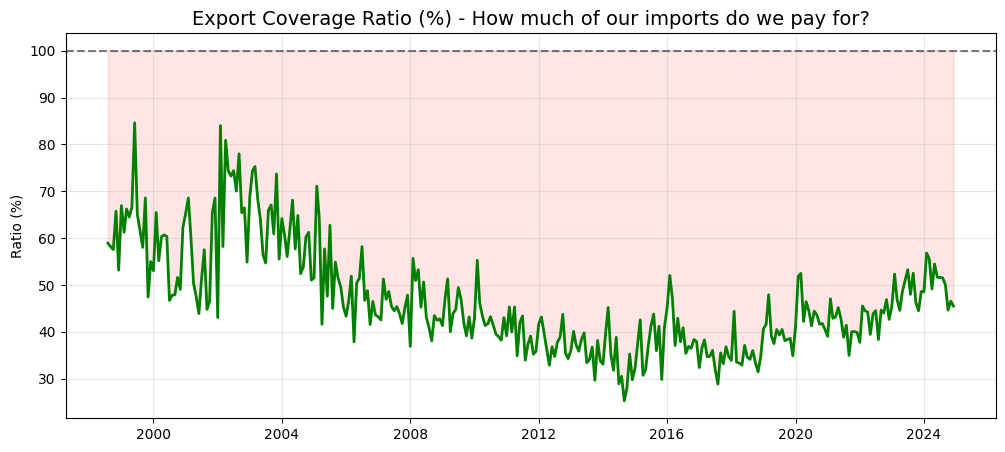

In [4]:
# VISUALIZATION 2: Coverage Ratio 
plt.figure(figsize=(12, 5))
plt.plot(df_trade.index, df_trade['export_import_ratio'], color='green', linewidth=2)
plt.axhline(100, color='black', linestyle='--', alpha=0.5, label='Balance Line')
plt.fill_between(df_trade.index, df_trade['export_import_ratio'], 100, where=(df_trade['export_import_ratio'] < 100), color='red', alpha=0.1)
plt.title('Export Coverage Ratio (%) - How much of our imports do we pay for?', fontsize=14)
plt.ylabel('Ratio (%)')
plt.grid(True, alpha=0.3)
plt.savefig('coverage_ratio.png')

### Underlying Trade Balance (Seasonally Adjusted)
To understand the structural health of Kenya's trade, we must look past the "noise" of monthly fluctuations. By applying a seasonal decomposition, we isolate the Trend, which represents the long-term direction of the trade deficit regardless of whether it's a holiday season or a harvest month.

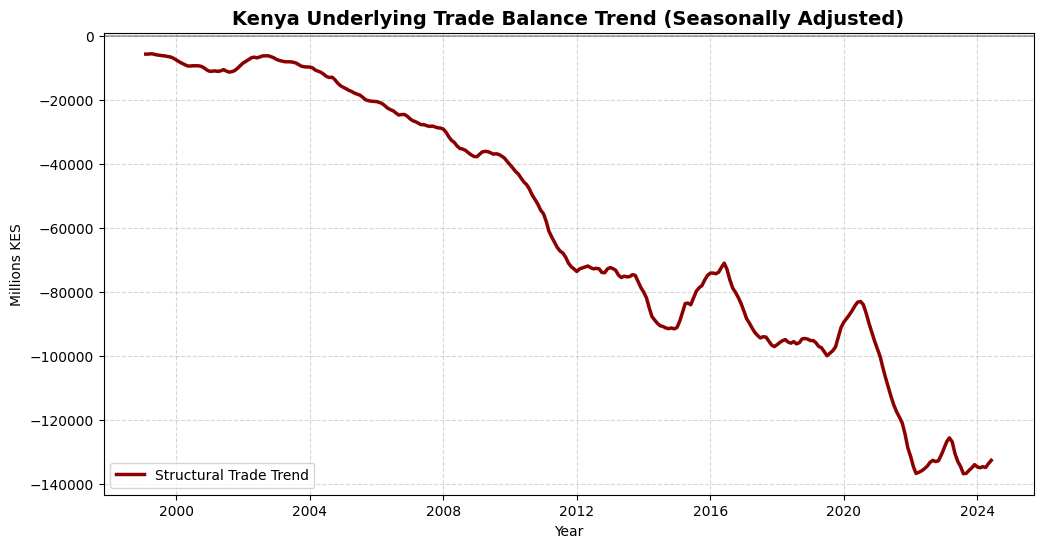

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from pathlib import Path

# 1. Path Management
BASE_DIR = Path.cwd().parent.parent
data_file = BASE_DIR / 'data' / 'cleaned' / 'trade_cleaned.csv'

# 2. Load and Prepare
df = pd.read_csv(data_file, index_col='date', parse_dates=True)

# 3. Seasonal Decomposition (Additive Model)
# We interpolate to ensure a continuous line for the math engine
ts_balance = df['trade_balance'].interpolate(method='linear')
decomposition = seasonal_decompose(ts_balance, model='additive', period=12)

# 4. Plotting the "Underlying" Trend
plt.figure(figsize=(12, 6))
plt.plot(decomposition.trend.index, decomposition.trend, 
         color='#8b0000', linewidth=2.5, label='Structural Trade Trend')

# Add a reference line at 0 (Balance)
plt.axhline(0, color='black', linestyle='-', alpha=0.3)

# Aesthetic formatting
plt.title('Kenya Underlying Trade Balance Trend (Seasonally Adjusted)', fontsize=14, fontweight='bold')
plt.ylabel('Millions KES')
plt.xlabel('Year')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='lower left')
plt.show()

## Trend Analysis: Structural vs. Cyclical Deficits
### The "Noise" Problem: 
Raw trade data is volatile. Import spikes occur every December (festive demand), and export surges happen during tea/coffee harvest seasons.

### The Trend Discovery: 
By isolating the Underlying Trend, we observe that the trade deficit is not just fluctuating—it is structurally widening. This indicates that the growth in domestic demand for foreign goods is consistently outstripping the growth of our export production capacity.

### Policy Implication: 
If the trend line slopes downward sharply, it suggests a "Heating Up" of the economy that may lead to currency depreciation unless offset by capital inflows (like FDI or Remittances).

## 2. Import Composition: Commercial vs. Government
This analysis separates imports into private sector (commercial) demand versus state-led procurement.

 By visualizing the govt_share versus commercial_share, we can identify if the trade deficit is being driven by private consumption or by large-scale government infrastructure/energy projects. A rising government share often correlates with fiscal expansion and external debt accumulation.

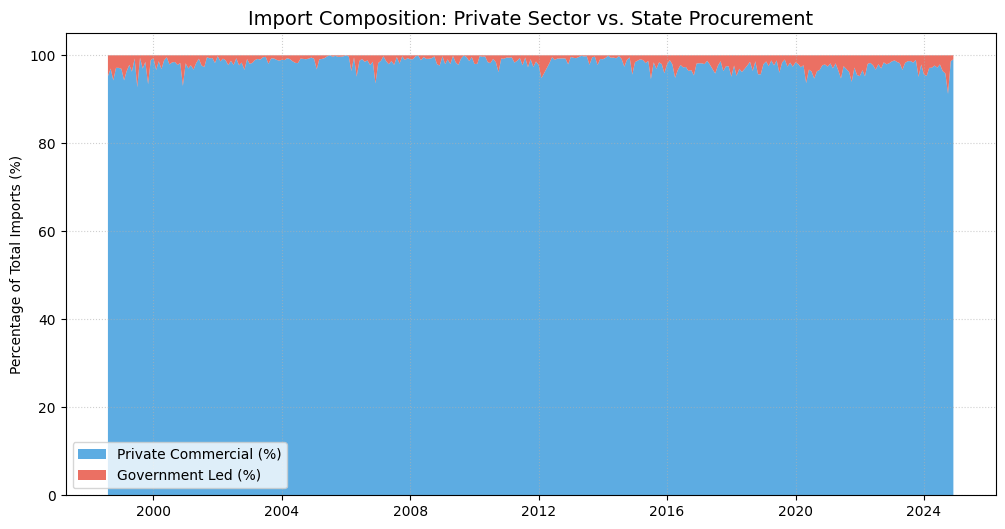

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Setup paths
BASE_DIR = Path.cwd().parent.parent
df_trade = pd.read_csv(BASE_DIR / 'data' / 'cleaned' / 'trade_cleaned.csv', index_col='date', parse_dates=True)

# 1. Calculate Shares
df_trade['govt_share'] = (df_trade['government_imports'] / df_trade['total_imports']) * 100
df_trade['commercial_share'] = 100 - df_trade['govt_share']

# 2. Plotting
plt.figure(figsize=(12, 6))
plt.stackplot(df_trade.index, df_trade['commercial_share'], df_trade['govt_share'], 
              labels=['Private Commercial (%)', 'Government Led (%)'], 
              colors=['#3498db', '#e74c3c'], alpha=0.8)

plt.title('Import Composition: Private Sector vs. State Procurement', fontsize=14)
plt.ylabel('Percentage of Total Imports (%)')
plt.legend(loc='lower left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## 3. Re-export Intensity (Hub Status)
Kenya serves as a gateway for East Africa. This analysis tracks the proportion of exports that are "re-exports" (goods imported then exported to neighbors like Uganda or Rwanda).

High Re-export Intensity indicates a strong logistics and transit sector. If re-exports are growing faster than domestic exports, it suggests Kenya is strengthening its position as a regional trade hub, even if domestic manufacturing growth is lagging.

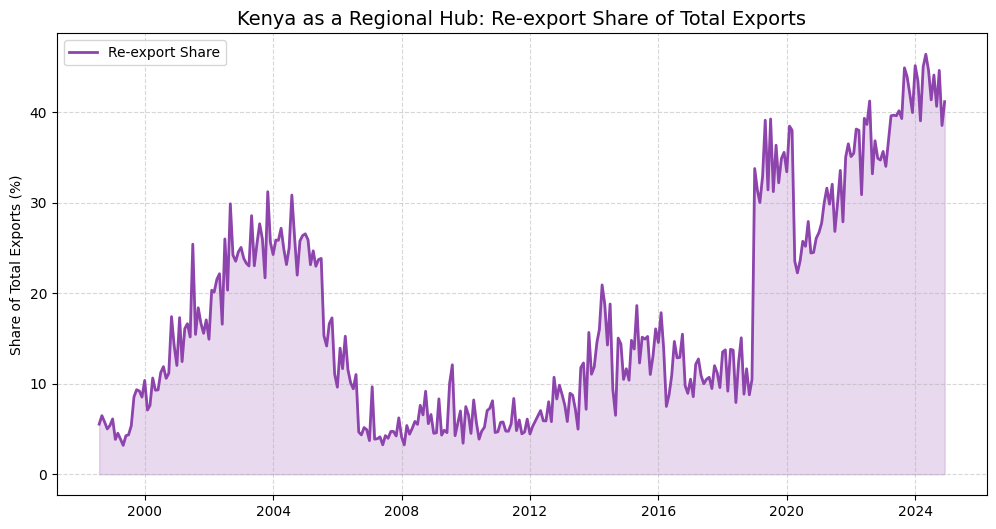

In [7]:
# df_trade is already loaded from the previous block
plt.figure(figsize=(12, 6))
plt.plot(df_trade.index, df_trade['re_export_share'], color='#8e44ad', linewidth=2, label='Re-export Share')
plt.fill_between(df_trade.index, df_trade['re_export_share'], color='#8e44ad', alpha=0.2)

plt.title('Kenya as a Regional Hub: Re-export Share of Total Exports', fontsize=14)
plt.ylabel('Share of Total Exports (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

## 4. The Trade-Monetary Linkage (External Pressure)
This is some sort of Holy Grail of this macro analysis: correlating the Trade Balance (real sector) with Net Foreign Assets (NFA) (monetary sector).

I merged the datasets to see how the trade deficit directly affects the Central Bank's foreign currency reserves:

##### Variable 1: Trade Balance (Monthly deficit/surplus).

##### Variable 2: Net Foreign Assets (NFA) from the monetary dataset.

### Insight
A high positive correlation between the trade balance and NFA suggests that the trade deficit is the primary driver of reserve depletion. When the trade gap widens, the NFA (a proxy for reserves) drops, putting pressure on the exchange rate.

✅ NFA Extracted successfully.


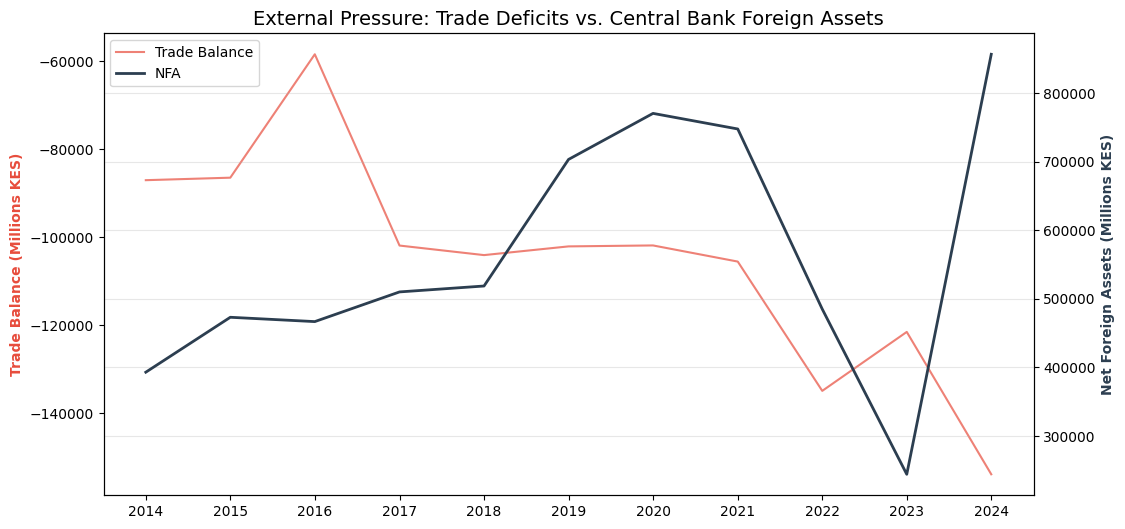

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Setup Paths
BASE_DIR = Path.cwd().parent.parent
trade_file = BASE_DIR / 'data' / 'cleaned' / 'trade_cleaned.csv'
monetary_raw = BASE_DIR / 'data' / 'cleaned' / 'monetary.csv'

# 2. Load Trade Data
df_trade = pd.read_csv(trade_file, index_col='date', parse_dates=True)

# 3. Robust Extraction for Monetary Data
def extract_monetary_indicator(path, label_name):
    df = pd.read_csv(path, low_memory=False)
    
    # Identify Years and Months
    years = df.columns.tolist()
    months = df.iloc[1].tolist()
    
    # Create valid date strings, skipping any non-date headers
    date_strings = []
    for y, m in zip(years[2:], months[2:]):
        # Handle cases where month might be 'Sept' (4 chars) instead of 'Sep' (3 chars)
        m_clean = str(m)[:3] 
        date_strings.append(f"{y}-{m_clean}")
    
    # Convert to dates - errors='coerce' turns bad text into NaT (Not a Time)
    dates = pd.to_datetime(date_strings, format='%Y-%b', errors='coerce')
    
    # Find the data row
    mask = df.iloc[:, 1].astype(str).str.contains(label_name, case=False, na=False)
    if not mask.any():
        raise KeyError(f"Could not find label '{label_name}' in the CSV.")
        
    values = df[mask].iloc[-1, 2:].values
    
    # Clean numeric data (handle commas and non-numeric junk)
    clean_values = []
    for v in values:
        try:
            s = str(v).replace(',', '').strip()
            clean_values.append(float(s) if s else np.nan)
        except:
            clean_values.append(np.nan)
            
    return pd.Series(clean_values[:len(dates)], index=dates, name=label_name).dropna()

# Extract NFA (Net Foreign Assets)
try:
    s_nfa = extract_monetary_indicator(monetary_raw, "Net Foreign assets")
    df_nfa = s_nfa.to_frame()
    print("✅ NFA Extracted successfully.")
except Exception as e:
    print(f"❌ Extraction Error: {e}")

# 4. Merge and Plot
combined = df_trade[['trade_balance']].merge(df_nfa, left_index=True, right_index=True)

fig, ax1 = plt.subplots(figsize=(12, 6))
line1, = ax1.plot(combined.index, combined['trade_balance'], color='#e74c3c', alpha=0.7, label='Trade Balance')
ax1.set_ylabel('Trade Balance (Millions KES)', color='#e74c3c', fontweight='bold')

ax2 = ax1.twinx()
line2, = ax2.plot(combined.index, combined['Net Foreign assets'], color='#2c3e50', linewidth=2, label='NFA')
ax2.set_ylabel('Net Foreign Assets (Millions KES)', color='#2c3e50', fontweight='bold')

lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', frameon=True, facecolor='white')

plt.title('External Pressure: Trade Deficits vs. Central Bank Foreign Assets', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()